In [10]:
import pandas as pd
import numpy as np

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [31]:
from pathlib import Path
import sqlite3


database_dir = Path("..") / "db.sqlite3"
conn = sqlite3.connect(database_dir)

query = """
    SELECT
        o.id AS order_id,
        oi.quantity,
        o.datetime AS order_datetime,
        p.price AS product_price,
        p.name AS product_name
    FROM restaurant_orderitem AS oi
    JOIN restaurant_order AS o
        ON o.id = oi.order_id
    JOIN restaurant_product AS p
        ON p.id = oi.product_id
    """

df = pd.read_sql_query(query, conn)
df.to_csv("restaurant_data.csv", index=False)
print(len(df))
conn.close()


74818


# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

<Axes: >

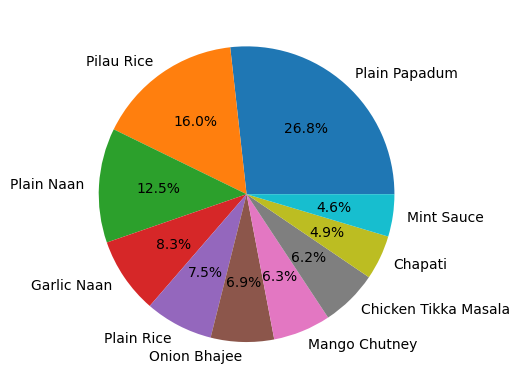

In [32]:
top_product = df.groupby("product_name")["quantity"].sum().sort_values(ascending=False).head(10)
top_product.plot.pie(autopct="%1.1f%%")

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

<Axes: >

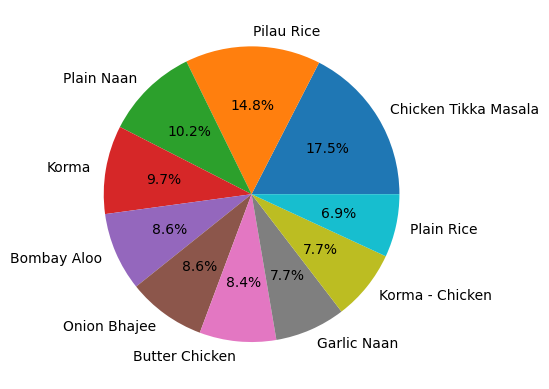

In [33]:
df["item_price"] = df["product_price"] * df["quantity"]
top_prices = df.groupby("product_name")["item_price"].sum().sort_values(ascending=False).head(10)
top_prices.plot.pie(autopct="%1.1f%%")

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

<Axes: xlabel='order_hour'>

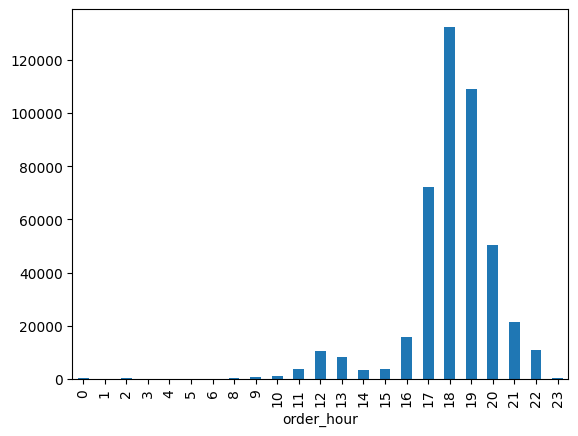

In [34]:
df["order_datetime"] = pd.to_datetime(df["order_datetime"])
df["order_hour"] = df["order_datetime"].dt.hour

income_by_hour = df.groupby("order_hour")["item_price"].sum()
income_by_hour.plot.bar()

# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

<Axes: xlabel='day_of_week'>

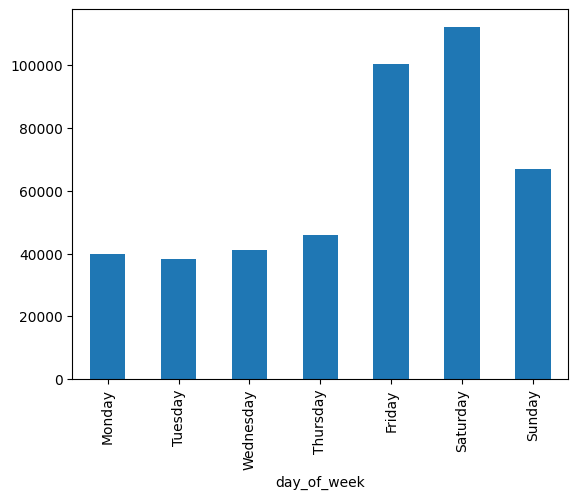

In [35]:
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]


df["day_of_week"] = df["order_datetime"].dt.day_name()
income_by_days = df.groupby("day_of_week")["item_price"].sum().reindex(days_order)
income_by_days.plot.bar()